<a href="https://colab.research.google.com/github/gcoelho3008/classification_neural_network/blob/main/classificacao_rede_neural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Vsão computacional com rede neural

### Extração de todos os pixels da imagem


In [65]:
import cv2
import numpy as np
import os
import zipfile
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab.patches import cv2_imshow
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

### Extração dos pixels das imagens

In [39]:
path = '/content/drive/MyDrive/Visão Computacional Guia Completo/Visão Computacional Guia Completo/Datasets/homer_bart_1.zip'
zip_object = zipfile.ZipFile(file=path, mode='r')
zip_object.extractall('./')
zip_object.close()

In [40]:
diretorio = '/content/homer_bart_1'
arquivos = [os.path.join(diretorio, f) for f in sorted(os.listdir(diretorio))]
print(arquivos)

['/content/homer_bart_1/.DS_Store', '/content/homer_bart_1/bart1.bmp', '/content/homer_bart_1/bart10.bmp', '/content/homer_bart_1/bart100.bmp', '/content/homer_bart_1/bart101.bmp', '/content/homer_bart_1/bart102.bmp', '/content/homer_bart_1/bart103.bmp', '/content/homer_bart_1/bart104.bmp', '/content/homer_bart_1/bart105.bmp', '/content/homer_bart_1/bart106.bmp', '/content/homer_bart_1/bart108.bmp', '/content/homer_bart_1/bart109.bmp', '/content/homer_bart_1/bart11.bmp', '/content/homer_bart_1/bart110.bmp', '/content/homer_bart_1/bart111.bmp', '/content/homer_bart_1/bart112.bmp', '/content/homer_bart_1/bart113.bmp', '/content/homer_bart_1/bart114.bmp', '/content/homer_bart_1/bart115.bmp', '/content/homer_bart_1/bart116.bmp', '/content/homer_bart_1/bart117.bmp', '/content/homer_bart_1/bart118.bmp', '/content/homer_bart_1/bart119.bmp', '/content/homer_bart_1/bart12.bmp', '/content/homer_bart_1/bart120.bmp', '/content/homer_bart_1/bart121.bmp', '/content/homer_bart_1/bart122.bmp', '/conte

In [41]:
type(arquivos)

list

In [42]:
largura, altura = 128, 128

In [43]:
imagens = []
classes = []

In [ ]:
for imagem_caminho in arquivos:
  #print(imagem_caminho)
  try:
    imagem = cv2.imread(imagem_caminho)
    (H, W) = imagem.shape[:2]
  except:
    continue

  imagem = cv2.resize(imagem, (largura, altura))
  imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)
  cv2_imshow(imagem)

  #transforma matriz para vetor
  imagem = imagem.ravel()
  #print(imagem.shape)

  imagens.append(imagem)
  nome_imagem = os.path.basename(os.path.normpath(imagem_caminho))
  #print(nome_imagem)

  if nome_imagem.startswith('b'):
    classe = 0
  else:
    classe = 1

  classes.append(classe)
  #print(classe)



In [ ]:
imagens

In [46]:
print(classes)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [47]:
imagens[100], classes[100]

(array([255, 255, 255, ..., 255, 255, 255], dtype=uint8), 0)

In [48]:
imagens[200], classes[200]

(array([255, 255, 255, ..., 255, 255, 255], dtype=uint8), 1)

In [49]:
type(imagens), type(classes)

(list, list)

In [50]:
# Previsores(pixels)
X = np.asarray(imagens)

# Respostas
y = np.asarray(classes)

In [51]:
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

In [52]:
X.shape, y.shape

((269, 16384), (269,))

In [55]:
print(y[:20])
print(type(y[0]))
print(np.unique(y))
print(len(np.unique(y)))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
<class 'numpy.int64'>
[0 1]
2


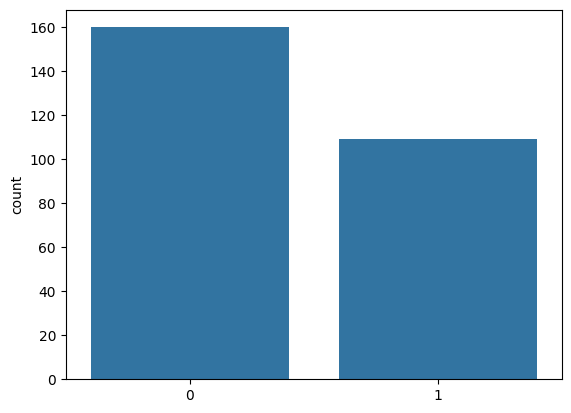

In [57]:
sns.countplot(x=y);

In [58]:
np.unique(y, return_counts=True)

(array([0, 1]), array([160, 109]))

### Normalização dos dados
Transformar escala de 0 a255 para 0 a1

In [59]:
X[0].max(), X[0].min

(np.uint8(255), <function ndarray.min>)

In [61]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [62]:
X[0].max(), X[0].min()

(np.float64(1.0000000000000002), np.float64(0.0))

In [63]:
X[1]

array([0.9947644 , 0.99479167, 0.99479167, ..., 0.99559471, 0.99595142,
       0.9950495 ])

### Base de Treino e Teste

In [64]:
X.shape

(269, 16384)

In [66]:
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(X, y, test_size = 0.2, random_state =1)

In [67]:
X_treinamento.shape, y_treinamento.shape

((215, 16384), (215,))

In [68]:
X_teste.shape, y_teste.shape

((54, 16384), (54,))